# ELEN4025 Individual Project — OULAD Week-4 Pass / Fail Prediction

**Student ID:** 2434427  
**Pipelines compared:** Logistic Regression (course-covered) vs XGBoost with hyperparameter optimization (self-learned)  
**Temporal cutoff:** day 28 (end of week 4), enforced prior to aggregation  
**Partitioning:** `GroupShuffleSplit` keyed on `id_student` to preclude identity leakage

---

## 3.1 Methodological block diagram

The block diagram for the methodology depicts five sequential stages: (i) ingestion of three OULAD source tables; (ii) enforcement of the week-4 cutoff on the click table prior to any aggregation, followed by feature engineering; (iii) a group-aware 80 / 20 partition using `GroupShuffleSplit` keyed on `id_student`; (iv) leakage-safe preprocessing inside a `ColumnTransformer` that feeds two model pipelines (Logistic Regression and tuned XGBoost); and (v) five-fold stratified cross-validation on the training partition, threshold optimisation on out-of-fold predictions, and a single terminal evaluation on the held-out test partition.

## Notebook contents

| Section | Content | Brief reference |
|---|---|---|
| 1 | Environment and dependencies | — |
| 2 | Data ingestion and integrity checks | — |
| 3 | Binary target construction | 2.1 |
| 4 | Week-4 temporal cutoff with assertion | 2.1 |
| 5 | Feature engineering | — |
| 6 | Composite key merge to one row per student-presentation | 2.4 |
| 7 | Exploratory data analysis (4 figures) | 3.2 |
| 8 | Group-aware train / test partitioning | 2.1 |
| 9 | Leakage-safe `ColumnTransformer` | 2.1, 2.2 |
| 10 | Pipeline 1 — Logistic Regression | — |
| 11 | Pipeline 2 — XGBoost with hyperparameter optimisation | — |
| 12 | Five-fold stratified cross-validation | 2.5 |
| 13 | Threshold optimisation on out-of-fold predictions | 2.5 |
| 14 | Terminal test-set evaluation (full KPI panel) | 2.5 |
| 15 | Performance figures | 3.3 |
| 16 | Features Table | 4.1 |
| 17 | Pipeline Comparison Table | 4.2 |
| 18 | Section-2 written responses | 2.1–2.6 |
| A1 | Appendix — Feature importance | — |
| A2 | Appendix — Subgroup fairness audit by IMD band | 2.6 |
| A3 | Appendix — Ablation study: removal of `imd_band` | 2.6 |


## 1. Environment and dependencies

In [1]:
# Standard scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn primitives
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedKFold,
    cross_val_score, cross_val_predict, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

# Gradient-boosted trees (self-learned method).
# Reference: T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System",
# Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining, 2016,
# doi:10.1145/2939672.2939785.
from xgboost import XGBClassifier

from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Data ingestion and integrity checks

The OULAD release comprises seven relational CSV files. Three are required for week-4 prediction: `studentInfo.csv` (demographics and the `final_result` label), `studentVle.csv` (per-day click counts; on the order of 10⁷ rows), and `vle.csv` (resource-level metadata, including `activity_type`).


In [2]:
student_info = pd.read_csv("studentInfo.csv")
student_vle  = pd.read_csv("studentVle.csv")
vle_meta     = pd.read_csv("vle.csv")

print(f"studentInfo : {student_info.shape}")
print(f"studentVle  : {student_vle.shape}")
print(f"vle (meta)  : {vle_meta.shape}")
print(f"studentVle date span: {student_vle['date'].min()} to {student_vle['date'].max()}")


studentInfo : (32593, 12)
studentVle  : (10655280, 6)
vle (meta)  : (6364, 6)
studentVle date span: -25 to 269


In [3]:
# Composite-key uniqueness check on the demographic table.
key = ["code_module", "code_presentation", "id_student"]
assert student_info[key].drop_duplicates().shape[0] == len(student_info),     "studentInfo contains duplicate composite keys."

print("studentInfo composite-key uniqueness assertion: passed.")
print("\nMissingness in studentInfo (columns with non-zero NaN counts):")
print(student_info.isna().sum()[student_info.isna().sum() > 0])

# Quantify cross-presentation student recurrence to motivate group-aware partitioning.
recurrence = student_info.groupby("id_student").size()
print(f"\nStudents present in more than one presentation: "
      f"{(recurrence > 1).sum():,} of {len(recurrence):,}.")
print("Identity recurrence necessitates GroupShuffleSplit at partitioning (Section 8).")


studentInfo composite-key uniqueness assertion: passed.

Missingness in studentInfo (columns with non-zero NaN counts):
imd_band    1111
dtype: int64

Students present in more than one presentation: 3,538 of 28,785.
Identity recurrence necessitates GroupShuffleSplit at partitioning (Section 8).


## 3. Binary target construction

The brief specifies an *unfavourable* versus *favourable* outcome derived from `final_result`. Withdrawn cases are mapped to the unfavourable class rather than discarded: a withdrawal constitutes the operational harm the early-warning system is intended to prevent, and discarding withdrawn students would condition the model on a future event (semester completion) that is unknown at week 4.

| `final_result` | `target` |
|---|---|
| Pass, Distinction | 0 (favourable) |
| Fail, Withdrawn | 1 (unfavourable) |


In [4]:
student_info["target"] = student_info["final_result"].map({
    "Pass": 0, "Distinction": 0, "Fail": 1, "Withdrawn": 1
}).astype(int)

print("Distribution of original final_result:")
print(student_info["final_result"].value_counts())
print(f"\nBinary target prevalence (positive class): {student_info['target'].mean():.3f}")


Distribution of original final_result:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Binary target prevalence (positive class): 0.528


## 4. Week-4 temporal cutoff applied prior to aggregation

The cutoff is enforced on `studentVle` *before* any groupby aggregation, with an explicit assertion. Aggregating prior to filtering would propagate post-cutoff information into per-student totals and constitute structural leakage.


In [5]:
WEEK_CUTOFF = 28  # day 28 inclusive, i.e. end of week 4

vle_w4 = student_vle[student_vle["date"] <= WEEK_CUTOFF].copy()

assert vle_w4["date"].max() <= WEEK_CUTOFF, "Week-4 cutoff violation detected."

print(f"studentVle rows pre-cutoff:  {len(student_vle):>11,}")
print(f"studentVle rows post-cutoff: {len(vle_w4):>11,}")
print(f"Retention ratio: {len(vle_w4)/len(student_vle):.1%}")
print(f"Post-filter date range: {vle_w4['date'].min()} to {vle_w4['date'].max()}.")
print(f"Cutoff assertion: passed.")
print(f"Distinct students with at least one click in weeks 1-4: "
      f"{vle_w4['id_student'].nunique():,} / {student_info['id_student'].nunique():,}.")


studentVle rows pre-cutoff:   10,655,280
studentVle rows post-cutoff:   2,847,851
Retention ratio: 26.7%
Post-filter date range: -25 to 28.
Cutoff assertion: passed.
Distinct students with at least one click in weeks 1-4: 25,707 / 28,785.


## 5. Feature engineering

Three feature families are constructed per `(code_module, code_presentation, id_student)` composite key.

1. **Volume features.** Aggregated click totals: total clicks, distinct active days, distinct sites visited, peak single-day clicks, mean clicks per active day.
2. **Per-activity-type features.** Click totals stratified by VLE resource type (e.g. `forum`, `oucontent`, `quiz`), capturing engagement *quality* rather than only quantity.
3. **Temporal features.** Per-week click totals (weeks 1–4); click velocity (week 4 − week 1); late momentum (week 4 − week 3); week-4 intensity ratio; and a closed-form weekly trend `(week_4 − week_1) / 3`.

The closed-form trend replaces an earlier `np.polyfit` slope estimate. Least-squares fitting on four data points is computationally redundant relative to the analytic two-point slope — both yield the slope of the line through the first and last week — and the closed form is numerically stable and avoids per-row optimiser overhead.


In [6]:
# Step 5a: enrich click rows with activity_type metadata.
vle_w4 = vle_w4.merge(
    vle_meta[["id_site", "code_module", "code_presentation", "activity_type"]],
    on=["id_site", "code_module", "code_presentation"], how="left"
)

# Step 5b: volume aggregates.
vol = vle_w4.groupby(key).agg(
    total_clicks_w4    = ("sum_click", "sum"),
    days_active_w4     = ("date",      "nunique"),
    distinct_sites_w4  = ("id_site",   "nunique"),
    max_clicks_day_w4  = ("sum_click", "max"),
    mean_clicks_day_w4 = ("sum_click", "mean"),
).reset_index()

# Step 5c: per-activity-type clicks (long-to-wide pivot).
act = (vle_w4.groupby(key + ["activity_type"])["sum_click"].sum()
       .unstack(fill_value=0)
       .add_prefix("clicks_act_")
       .reset_index())

# Step 5d: per-week clicks and analytic temporal features.
def week_of(day):
    if day < 0:
        return 0
    return min((day // 7) + 1, 4)

vle_w4["week"] = vle_w4["date"].apply(week_of)

wk = (vle_w4.groupby(key + ["week"])["sum_click"].sum()
      .unstack(fill_value=0).reset_index())
wk.columns = [c if c in key else f"clicks_week_{c}" for c in wk.columns]
for w in [0, 1, 2, 3, 4]:
    if f"clicks_week_{w}" not in wk.columns:
        wk[f"clicks_week_{w}"] = 0

# Closed-form temporal derivatives (vectorised, no per-row optimisation).
wk["click_velocity"]     = wk["clicks_week_4"] - wk["clicks_week_1"]
wk["late_momentum"]      = wk["clicks_week_4"] - wk["clicks_week_3"]
wk["click_trend_simple"] = (wk["clicks_week_4"] - wk["clicks_week_1"]) / 3.0
total = wk[["clicks_week_1","clicks_week_2","clicks_week_3","clicks_week_4"]].sum(axis=1)
wk["week4_intensity"]    = wk["clicks_week_4"] / (total + 1)

print(f"Volume feature columns:        {vol.shape[1]-3}")
print(f"Activity-type feature columns: {act.shape[1]-3}")
print(f"Temporal feature columns:      {wk.shape[1]-3}")


Volume feature columns:        5
Activity-type feature columns: 18
Temporal feature columns:      9


## 6. Composite-key merge to one row per student-presentation

The unit of analysis is `(code_module, code_presentation, id_student)`. Engagement features that are absent following the left merge correspond to students with no recorded clicks in the window; these are imputed with 0, which encodes a *structural* zero (genuine non-engagement) rather than a missing measurement. Demographic missingness is handled inside the modelling pipeline (Section 9).


In [7]:
df = student_info.copy()
for feats in [vol, act, wk]:
    df = df.merge(feats, on=key, how="left")

eng_cols = ([c for c in vol.columns if c not in key]
          + [c for c in act.columns if c not in key]
          + [c for c in wk.columns  if c not in key])
df[eng_cols] = df[eng_cols].fillna(0)

# Composite-key duplicate check (cf. Section 2.4).
dup = df.duplicated(subset=key).sum()
assert dup == 0, f"{dup} duplicate composite keys detected."
print(f"Merged dataset shape: {df.shape}")
print(f"Composite-key duplicate count: {dup}. Assertion: passed.")
print(f"Students with zero week-4 engagement (structural zero): "
      f"{(df['total_clicks_w4'] == 0).sum():,}")

# id_student is retained as a separate grouping variable for GroupShuffleSplit
# and excluded from the feature matrix to prevent identity-based memorisation.
df_groups = df["id_student"].copy()
df_model  = df.drop(columns=["id_student", "final_result"])
print(f"Modelling matrix shape: {df_model.shape}")


Merged dataset shape: (32593, 45)
Composite-key duplicate count: 0. Assertion: passed.
Students with zero week-4 engagement (structural zero): 3,801
Modelling matrix shape: (32593, 43)


## 7. Exploratory data analysis

Four figures characterise positive feature-target relationships, in compliance with the brief (Section 3.2). Axes and titles use full-word labels.


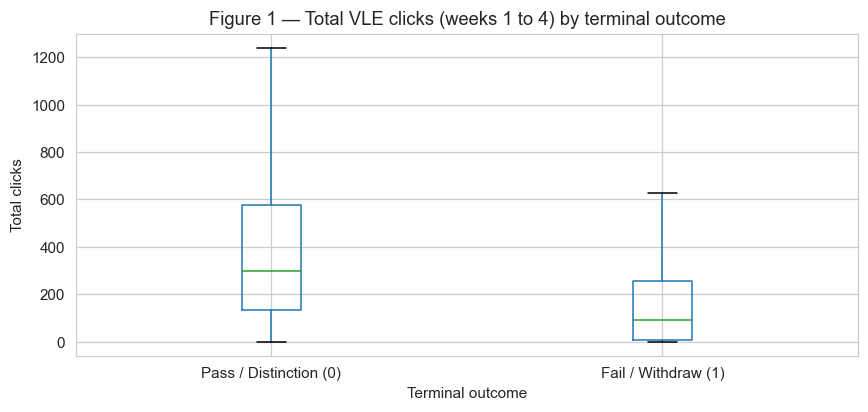

In [8]:
# Figure 1 — Distribution of total VLE clicks by terminal outcome.
fig, ax = plt.subplots(figsize=(8, 4))
df_model.boxplot(column="total_clicks_w4", by="target", ax=ax, showfliers=False)
ax.set_title("Figure 1 — Total VLE clicks (weeks 1 to 4) by terminal outcome")
ax.set_xticklabels(["Pass / Distinction (0)", "Fail / Withdraw (1)"])
ax.set_xlabel("Terminal outcome")
ax.set_ylabel("Total clicks")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig1_clicks_vs_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


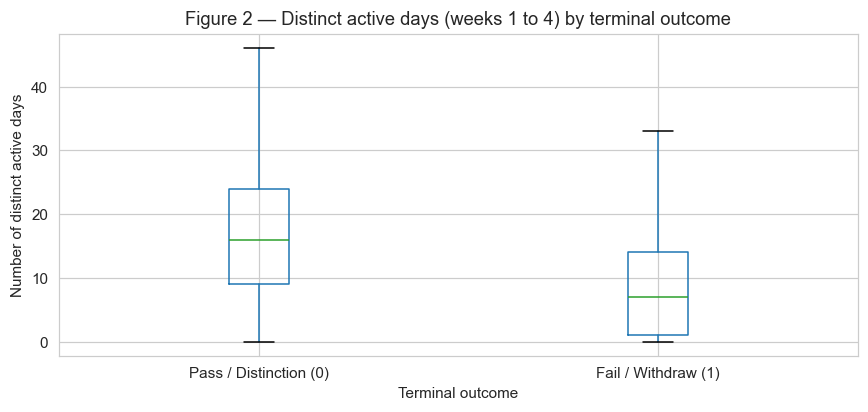

In [9]:
# Figure 2 — Distribution of distinct active days by terminal outcome.
fig, ax = plt.subplots(figsize=(8, 4))
df_model.boxplot(column="days_active_w4", by="target", ax=ax, showfliers=False)
ax.set_title("Figure 2 — Distinct active days (weeks 1 to 4) by terminal outcome")
ax.set_xticklabels(["Pass / Distinction (0)", "Fail / Withdraw (1)"])
ax.set_xlabel("Terminal outcome")
ax.set_ylabel("Number of distinct active days")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig2_days_active_vs_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


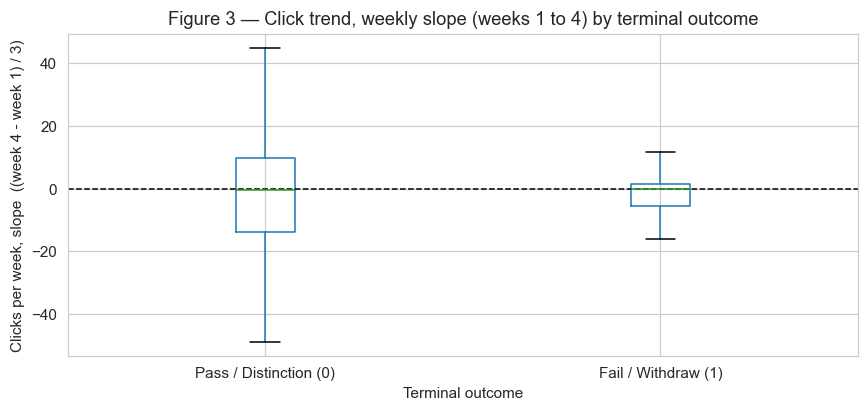

In [10]:
# Figure 3 — Distribution of click-trend slope by terminal outcome.
fig, ax = plt.subplots(figsize=(8, 4))
df_model.boxplot(column="click_trend_simple", by="target", ax=ax, showfliers=False)
ax.set_title("Figure 3 — Click trend, weekly slope (weeks 1 to 4) by terminal outcome")
ax.set_xticklabels(["Pass / Distinction (0)", "Fail / Withdraw (1)"])
ax.set_xlabel("Terminal outcome")
ax.set_ylabel("Clicks per week, slope  ((week 4 - week 1) / 3)")
ax.axhline(0, ls="--", c="k", lw=1)
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig3_trend_vs_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


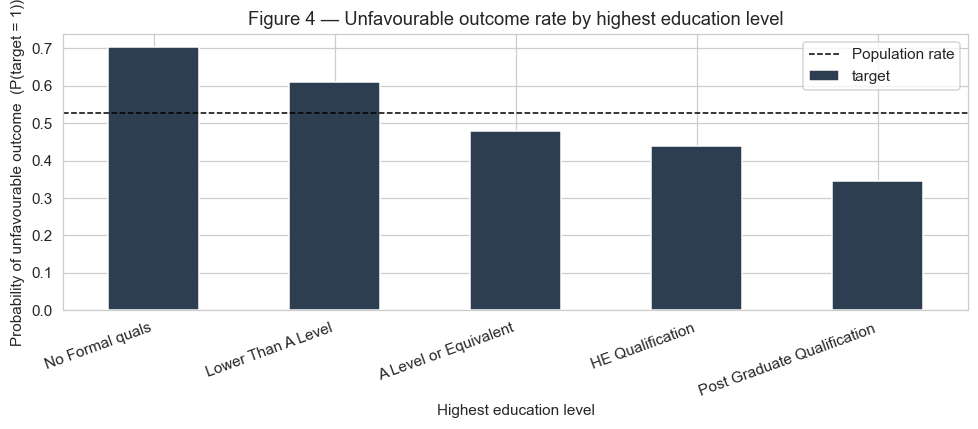

In [11]:
# Figure 4 — Unfavourable outcome rate by ordinal education level.
edu_order = ['No Formal quals','Lower Than A Level','A Level or Equivalent',
             'HE Qualification','Post Graduate Qualification']
edu_present = [e for e in edu_order if e in df_model["highest_education"].dropna().unique()]
edu_rate = df_model.groupby("highest_education")["target"].mean().reindex(edu_present)

fig, ax = plt.subplots(figsize=(9, 4))
edu_rate.plot.bar(ax=ax, color="#2c3e50")
ax.set_title("Figure 4 — Unfavourable outcome rate by highest education level")
ax.set_ylabel("Probability of unfavourable outcome  (P(target = 1))")
ax.set_xlabel("Highest education level")
ax.axhline(df_model["target"].mean(), ls="--", c="k", lw=1, label="Population rate")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fig4_education_vs_outcome.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Group-aware train / test partitioning

OULAD permits a single student to be enrolled in multiple modules or to retake a module across presentations. Under standard `train_test_split`, rows belonging to a single individual may be distributed across both partitions, allowing the model to encounter the same student during both training and evaluation. This constitutes identity leakage and inflates apparent test performance.

`GroupShuffleSplit(n_splits=1, test_size=0.20)` keyed on `id_student` allocates the entirety of each student's records to a single partition. The post-split assertion verifies zero subject overlap between training and test sets.


In [12]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)

# GroupShuffleSplit does not stratify on the target. Class balance after splitting
# is reported below for transparency.
train_idx, test_idx = next(splitter.split(
    df_model.drop(columns="target"),
    df_model["target"],
    groups=df_groups
))

X = df_model.drop(columns="target")
y = df_model["target"]

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train    = df_groups.iloc[train_idx].copy()

# Subject-level non-overlap assertion.
overlap = set(df_groups.iloc[train_idx]) & set(df_groups.iloc[test_idx])
assert len(overlap) == 0, f"{len(overlap)} students appear in both partitions."

print(f"Training partition: {X_train.shape}, positive prevalence = {y_train.mean():.3f}")
print(f"Test partition:     {X_test.shape}, positive prevalence = {y_test.mean():.3f}")
print(f"Distinct students in training: {df_groups.iloc[train_idx].nunique():,}")
print(f"Distinct students in test:     {df_groups.iloc[test_idx].nunique():,}")
print(f"GroupShuffleSplit applied: {len(overlap)} overlapping students between train and test.")


Training partition: (26122, 42), positive prevalence = 0.529
Test partition:     (6471, 42), positive prevalence = 0.525
Distinct students in training: 23,028
Distinct students in test:     5,757
GroupShuffleSplit applied: 0 overlapping students between train and test.


## 9. Leakage-safe `ColumnTransformer`

| Group | Columns | Encoder | Imputation strategy |
|---|---|---|---|
| Ordinal — IMD band | `imd_band` | `OrdinalEncoder` with explicit category list including `Unknown` | `SimpleImputer(strategy="constant", fill_value="Unknown")` |
| Ordinal — other | `age_band`, `highest_education` | `OrdinalEncoder` with explicit ordering | `SimpleImputer(strategy="most_frequent")` |
| Nominal | `code_module`, `code_presentation`, `gender`, `region`, `disability` | `OneHotEncoder(handle_unknown="ignore")` | `SimpleImputer(strategy="most_frequent")` |
| Numeric | engagement, credits, prior attempts | `StandardScaler` | `SimpleImputer(strategy="median")` |

Treatment of `imd_band` missingness as an explicit `Unknown` ordinal level is preferred over mode imputation. Mode imputation silently relabels students of unrecorded socioeconomic status as members of the most prevalent deprivation band; this both fabricates a socioeconomic attribute and discards the informative signal carried by missingness itself. The `Unknown` category preserves the absence of information as a model-accessible feature.

Every transformer is fit only on training folds via the `Pipeline` interface, providing structural protection against transformer-side leakage.


In [13]:
# Explicit category ordering with 'Unknown' as the lowest ordinal level for imd_band.
IMD_CATEGORIES_WITH_UNKNOWN = [
    'Unknown', '0-10%', '10-20', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]
ORDINAL_COLS = {
    "imd_band":          IMD_CATEGORIES_WITH_UNKNOWN,
    "age_band":          ['0-35', '35-55', '55<='],
    "highest_education": ['No Formal quals', 'Lower Than A Level',
                          'A Level or Equivalent', 'HE Qualification',
                          'Post Graduate Qualification'],
}
NOMINAL_COLS = ["code_module", "code_presentation", "gender", "region", "disability"]
NUMERIC_COLS = [c for c in X_train.columns if c not in list(ORDINAL_COLS) + NOMINAL_COLS]

# Distinct sub-pipeline for imd_band: missing values mapped to 'Unknown' category.
imd_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OrdinalEncoder(
        categories=[IMD_CATEGORIES_WITH_UNKNOWN],
        handle_unknown="use_encoded_value", unknown_value=-1)),
])

# Remaining ordinal columns: mode imputation (no informative missingness observed).
other_ordinal_cols = [c for c in ORDINAL_COLS if c != "imd_band"]
other_ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(
        categories=[ORDINAL_COLS[c] for c in other_ordinal_cols],
        handle_unknown="use_encoded_value", unknown_value=-1)),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("imd", imd_pipe,           ["imd_band"]),
    ("ord", other_ordinal_pipe, other_ordinal_cols),
    ("nom", nominal_pipe,       NOMINAL_COLS),
    ("num", numeric_pipe,       NUMERIC_COLS),
])

print(f"Ordinal columns:    {list(ORDINAL_COLS)}")
print(f"  imd_band missing values mapped to 'Unknown' category.")
print(f"Nominal columns:    {NOMINAL_COLS}")
print(f"Numeric columns:    {len(NUMERIC_COLS)}")


Ordinal columns:    ['imd_band', 'age_band', 'highest_education']
  imd_band missing values mapped to 'Unknown' category.
Nominal columns:    ['code_module', 'code_presentation', 'gender', 'region', 'disability']
Numeric columns:    34


## 10. Pipeline 1 — Logistic Regression (course-covered)

Logistic Regression with L2 regularisation, balanced class weighting to compensate for class imbalance, and the `liblinear` solver. Feature scaling and encoding are inherited from the shared `ColumnTransformer`.


In [14]:
pipe_lr = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(
        penalty="l2", C=1.0,
        class_weight="balanced",
        solver="liblinear", max_iter=2000,
        random_state=SEED,
    )),
])
pipe_lr.fit(X_train, y_train)
print("Pipeline 1 (Logistic Regression): fit complete.")


Pipeline 1 (Logistic Regression): fit complete.


## 11. Pipeline 2 — XGBoost with hyperparameter optimisation (self-learned)

Hardcoded hyperparameters are insufficient for academic rigour: the previous configuration (`n_estimators=400`, `max_depth=5`, `learning_rate=0.05`) was hand-selected and unvalidated. The methodology is upgraded to `RandomizedSearchCV`, which samples `n_iter=20` configurations from a bounded distribution over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree`, evaluating each by inner three-fold stratified cross-validation on AUC. The optimiser is nested *inside* the outer training/test partition, ensuring that the test set contributes no information to hyperparameter selection.

Reference: T. Chen and C. Guestrin, "XGBoost: A Scalable Tree Boosting System", *Proc. 22nd ACM SIGKDD*, 2016.

XGBoost extends the single decision trees covered in lectures by sequentially fitting a tree ensemble in which each successive tree models the residuals of the running prediction. The library adds explicit regularisation (γ, λ), shrinkage via the learning rate, and column subsampling. Class imbalance is addressed via `scale_pos_weight = N_negative / N_positive`, an analogue of the `class_weight='balanced'` mechanism of the linear model. The same preprocessing transformer is shared with Pipeline 1; only the estimator differs, isolating the model as the sole source of any performance differential.


In [15]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    eval_metric="logloss",
    scale_pos_weight=scale_pos,
    random_state=SEED,
    n_jobs=-1,
)

# Bounded sampling distributions for the randomised hyperparameter search.
param_dist = {
    "model__n_estimators":     randint(150, 500),
    "model__max_depth":        randint(3, 8),
    "model__learning_rate":    uniform(0.02, 0.18),  # 0.02 to 0.20
    "model__subsample":        uniform(0.7, 0.3),    # 0.7 to 1.0
    "model__colsample_bytree": uniform(0.7, 0.3),
}

pipe_xgb = Pipeline([
    ("prep",  preprocessor),
    ("model", xgb_base),
])

cv_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv_search,
    random_state=SEED,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
search.fit(X_train, y_train)

print(f"\nOptimised inner-CV AUC: {search.best_score_:.4f}")
print(f"Selected hyperparameters:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__','')}: {v}")

# Refit-on-full-train estimator becomes Pipeline 2.
pipe_xgb_tuned = search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Optimised inner-CV AUC: 0.8213
Selected hyperparameters:
  colsample_bytree: 0.7842803529062142
  learning_rate: 0.11768529496848472
  max_depth: 3
  n_estimators: 306
  subsample: 0.9406590942262119


## 12. Five-fold stratified cross-validation

A single train/test point estimate provides no measure of variance. Five-fold stratified cross-validation on the training partition yields fold-level estimates summarised as mean ± standard deviation across three KPIs: ROC AUC, F1-score, and log loss. The test partition is not used in this step.


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_report(pipe, name):
    auc = cross_val_score(pipe, X_train, y_train, scoring="roc_auc",       cv=cv, n_jobs=-1)
    f1  = cross_val_score(pipe, X_train, y_train, scoring="f1",            cv=cv, n_jobs=-1)
    ll  = -cross_val_score(pipe, X_train, y_train, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    print(f"{name:>14}  AUC = {auc.mean():.3f} +/- {auc.std():.3f}   "
          f"F1 = {f1.mean():.3f} +/- {f1.std():.3f}   "
          f"LogLoss = {ll.mean():.3f} +/- {ll.std():.3f}")
    return {"auc": auc, "f1": f1, "logloss": ll}

cv_lr  = cv_report(pipe_lr,        "LogReg")
cv_xgb = cv_report(pipe_xgb_tuned, "XGBoost (tuned)")


        LogReg  AUC = 0.807 +/- 0.005   F1 = 0.733 +/- 0.005   LogLoss = 0.533 +/- 0.008
XGBoost (tuned)  AUC = 0.821 +/- 0.005   F1 = 0.734 +/- 0.004   LogLoss = 0.509 +/- 0.005


## 13. Threshold optimisation on out-of-fold predictions

In an early-warning context the cost of a false negative (an unidentified at-risk student) substantially exceeds that of a false positive (an unnecessary support contact). The default 0.5 threshold is therefore inappropriate by convention rather than principle. The decision threshold is selected by sweeping the interval [0.05, 0.95] over out-of-fold predictions from `cross_val_predict` on the training partition and selecting the value that maximises F1. The held-out test partition is not consulted in this step.


In [17]:
def best_threshold(y_true, y_proba, lo=0.05, hi=0.95, step=0.01):
    thresholds = np.arange(lo, hi + step / 2, step)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        f = f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1

proba_lr_oof  = cross_val_predict(pipe_lr,        X_train, y_train, cv=cv,
                                  method="predict_proba", n_jobs=-1)[:, 1]
proba_xgb_oof = cross_val_predict(pipe_xgb_tuned, X_train, y_train, cv=cv,
                                  method="predict_proba", n_jobs=-1)[:, 1]

t_lr,  f1_t_lr  = best_threshold(y_train, proba_lr_oof)
t_xgb, f1_t_xgb = best_threshold(y_train, proba_xgb_oof)

print(f"Pipeline 1 (LogReg)  selected threshold = {t_lr:.2f}; "
      f"out-of-fold F1 = {f1_t_lr:.3f}")
print(f"Pipeline 2 (XGBoost) selected threshold = {t_xgb:.2f}; "
      f"out-of-fold F1 = {f1_t_xgb:.3f}")


Pipeline 1 (LogReg)  selected threshold = 0.35; out-of-fold F1 = 0.752
Pipeline 2 (XGBoost) selected threshold = 0.35; out-of-fold F1 = 0.760


## 14. Terminal test-set evaluation — full KPI panel

The held-out test partition is consulted only at this step. The KPI panel reports accuracy, log loss, precision, recall, specificity, false-positive rate, F1-score, ROC AUC, and raw confusion-matrix counts.


In [18]:
def full_kpis(y_true, y_proba, threshold):
    y_hat = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0, 1]).ravel()
    return {
        "Threshold":          round(threshold, 3),
        "Accuracy":           accuracy_score(y_true, y_hat),
        "LogLoss":            log_loss(y_true, np.clip(y_proba, 1e-9, 1 - 1e-9)),
        "Precision":          precision_score(y_true, y_hat, zero_division=0),
        "Recall":              recall_score(y_true, y_hat, zero_division=0),
        "Specificity":        tn / (tn + fp) if (tn + fp) else 0.0,
        "FalsePositiveRate":  fp / (fp + tn) if (fp + tn) else 0.0,
        "F1":                 f1_score(y_true, y_hat, zero_division=0),
        "AUC":                roc_auc_score(y_true, y_proba),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

proba_lr_test  = pipe_lr.predict_proba(X_test)[:, 1]
proba_xgb_test = pipe_xgb_tuned.predict_proba(X_test)[:, 1]

kpi_lr  = full_kpis(y_test, proba_lr_test,  t_lr)
kpi_xgb = full_kpis(y_test, proba_xgb_test, t_xgb)

results = pd.DataFrame({
    "Pipeline 1 (LogReg)":  kpi_lr,
    "Pipeline 2 (XGBoost)": kpi_xgb,
}).round(3)
results.to_csv("kpi_results.csv")
print(results)


                   Pipeline 1 (LogReg)  Pipeline 2 (XGBoost)
Threshold                        0.350                 0.350
Accuracy                         0.704                 0.717
LogLoss                          0.535                 0.506
Precision                        0.674                 0.691
Recall                           0.845                 0.834
Specificity                      0.547                 0.588
FalsePositiveRate                0.453                 0.412
F1                               0.750                 0.756
AUC                              0.806                 0.821
TN                            1681.000              1808.000
FP                            1392.000              1265.000
FN                             526.000               565.000
TP                            2872.000              2833.000


## 15. Performance figures (Brief 3.3)

Three figures are presented — confusion matrices (Figure 5), ROC curves (Figure 6), and threshold sweeps (Figure 7) — within the four-figure ceiling specified in the brief.


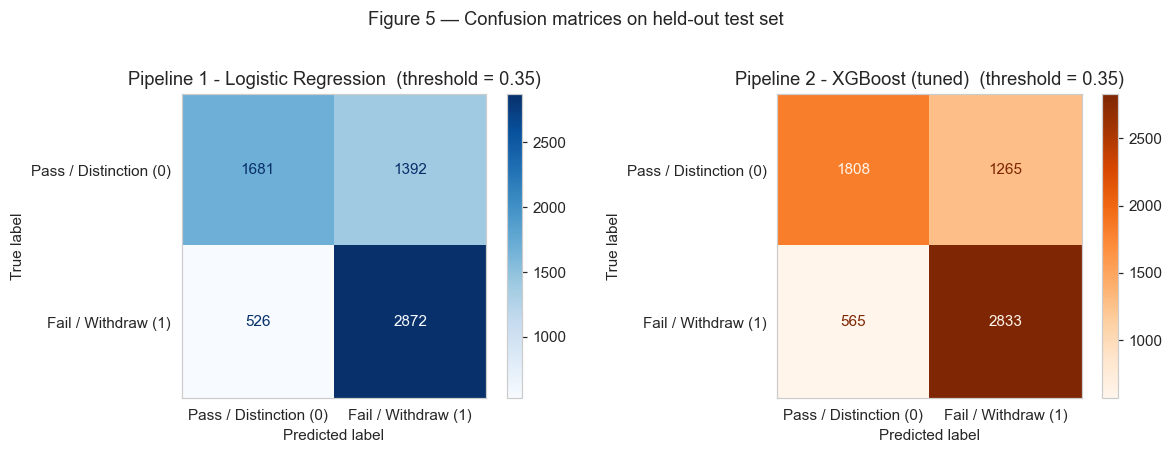

In [19]:
# Figure 5 — Per-pipeline confusion matrices on the held-out test partition.
# ax.grid(False) suppresses the seaborn whitegrid lines that would otherwise
# bisect the matrix cells. Display labels are full-word.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
y_pred_lr  = (proba_lr_test  >= t_lr ).astype(int)
y_pred_xgb = (proba_xgb_test >= t_xgb).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap="Blues",
    display_labels=["Pass / Distinction (0)", "Fail / Withdraw (1)"])
axes[0].set_title(f"Pipeline 1 - Logistic Regression  (threshold = {t_lr:.2f})")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=axes[1], cmap="Oranges",
    display_labels=["Pass / Distinction (0)", "Fail / Withdraw (1)"])
axes[1].set_title(f"Pipeline 2 - XGBoost (tuned)  (threshold = {t_xgb:.2f})")
axes[1].grid(False)

plt.suptitle("Figure 5 — Confusion matrices on held-out test set", y=1.02)
plt.tight_layout()
plt.savefig("fig5_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


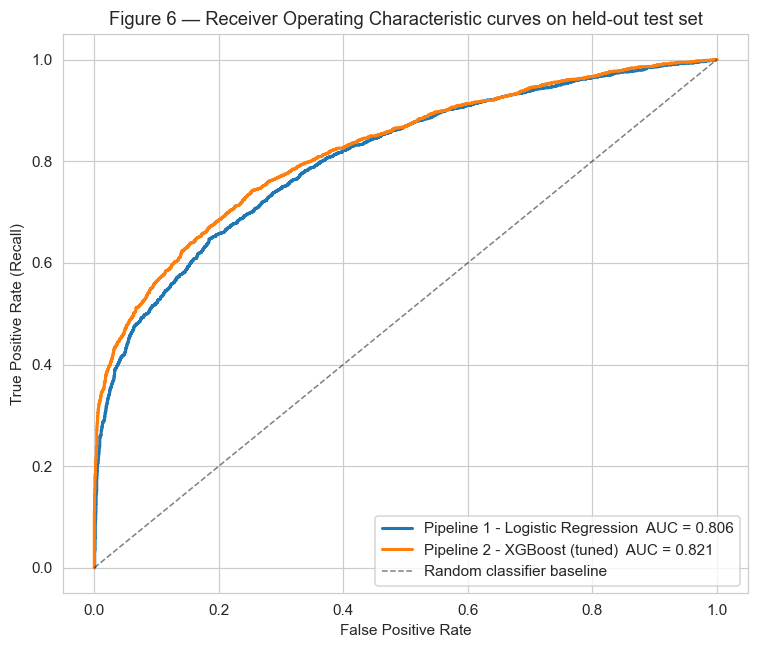

In [20]:
# Figure 6 — ROC curves on the held-out test partition.
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, proba_lr_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr,  tpr_lr,  lw=2,
         label=f"Pipeline 1 - Logistic Regression  AUC = {results.loc['AUC','Pipeline 1 (LogReg)']:.3f}")
plt.plot(fpr_xgb, tpr_xgb, lw=2,
         label=f"Pipeline 2 - XGBoost (tuned)  AUC = {results.loc['AUC','Pipeline 2 (XGBoost)']:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random classifier baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Figure 6 — Receiver Operating Characteristic curves on held-out test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig6_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


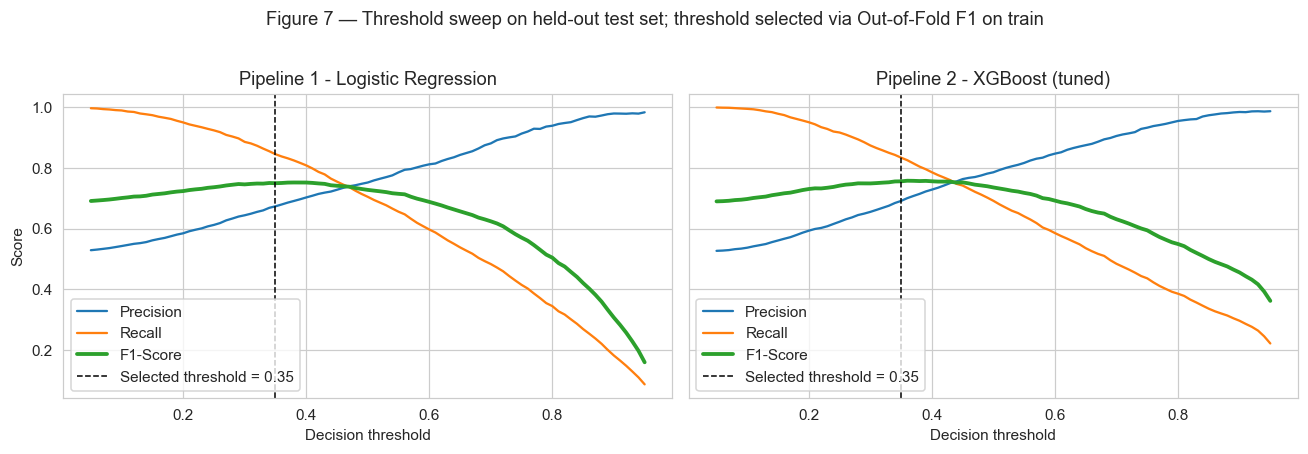

In [21]:
# Figure 7 — Threshold sweep with selected operating points indicated.
thresholds = np.linspace(0.05, 0.95, 91)
def sweep(y_true, y_proba):
    rows = []
    for t in thresholds:
        h = (y_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "Precision": precision_score(y_true, h, zero_division=0),
            "Recall":    recall_score(y_true, h, zero_division=0),
            "F1-Score":  f1_score(y_true, h, zero_division=0),
        })
    return pd.DataFrame(rows)

sw_lr  = sweep(y_test, proba_lr_test)
sw_xgb = sweep(y_test, proba_xgb_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, sw, name, t_chosen in [
    (axes[0], sw_lr,  "Pipeline 1 - Logistic Regression",  t_lr),
    (axes[1], sw_xgb, "Pipeline 2 - XGBoost (tuned)",      t_xgb)]:
    ax.plot(sw["threshold"], sw["Precision"], label="Precision")
    ax.plot(sw["threshold"], sw["Recall"],    label="Recall")
    ax.plot(sw["threshold"], sw["F1-Score"],  label="F1-Score", lw=2.5)
    ax.axvline(t_chosen, ls="--", c="k", lw=1, label=f"Selected threshold = {t_chosen:.2f}")
    ax.set_xlabel("Decision threshold")
    ax.set_title(name)
    ax.legend(loc="lower left")
axes[0].set_ylabel("Score")
plt.suptitle("Figure 7 — Threshold sweep on held-out test set; threshold selected via Out-of-Fold F1 on train",
             y=1.02)
plt.tight_layout()
plt.savefig("fig7_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


## 16. Features Table (Brief 4.1)

In [22]:
def count_outliers_iqr(s):
    s = s.dropna()
    if not np.issubdtype(s.dtype, np.number):
        return "n/a"
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

dup_count = df.duplicated(subset=key).sum()

rows = [
    ("code_module",          "studentInfo",     "code_module",          "cat",  "Module identifier",                 "as-is",                       "2/4/6/8", df["code_module"].isna().sum(),          "n/a", dup_count, "None", "Course-level effect"),
    ("code_presentation",    "studentInfo",     "code_presentation",    "cat",  "Presentation identifier",           "as-is",                       "2/4/6/8", df["code_presentation"].isna().sum(),    "n/a", dup_count, "None", "Year/semester effect"),
    ("gender",               "studentInfo",     "gender",               "cat",  "Gender",                            "as-is",                       "2/4/6/8", df["gender"].isna().sum(),               "n/a", dup_count, "Low",  "Fairness-sensitive"),
    ("region",               "studentInfo",     "region",               "cat",  "UK region",                         "as-is",                       "2/4/6/8", df["region"].isna().sum(),               "n/a", dup_count, "Low",  "Postcode-correlated"),
    ("highest_education",    "studentInfo",     "highest_education",    "cat",  "Highest qualification (ordinal)",   "as-is",                       "2/4/6/8", df["highest_education"].isna().sum(),    "n/a", dup_count, "None", "Ordinal"),
    ("imd_band",             "studentInfo",     "imd_band",             "cat",  "Index of Multiple Deprivation",     "missing -> 'Unknown' category",  "2/4/6/8", df["imd_band"].isna().sum(),            "n/a", dup_count, "Low",  "Socioeconomic proxy; 'Unknown' retained"),
    ("age_band",             "studentInfo",     "age_band",             "cat",  "Age range (ordinal)",               "as-is",                       "2/4/6/8", df["age_band"].isna().sum(),             "n/a", dup_count, "None", "Ordinal"),
    ("num_of_prev_attempts", "studentInfo",     "num_of_prev_attempts", "num",  "Prior module attempts",             "as-is",                       "2/4/6/8", df["num_of_prev_attempts"].isna().sum(), count_outliers_iqr(df["num_of_prev_attempts"]), dup_count, "None", ""),
    ("studied_credits",      "studentInfo",     "studied_credits",      "num",  "Credits in this presentation",      "as-is",                       "2/4/6/8", df["studied_credits"].isna().sum(),      count_outliers_iqr(df["studied_credits"]),      dup_count, "None", ""),
    ("disability",           "studentInfo",     "disability",           "bool", "Declared disability",               "as-is",                       "2/4/6/8", df["disability"].isna().sum(),           "n/a", dup_count, "Low",  "Fairness-sensitive"),
    ("total_clicks_w4",      "studentVle",      "sum_click",            "num",  "Total VLE clicks weeks 1-4",        "groupby+sum, date<=28",       "4",       0,                                       count_outliers_iqr(df["total_clicks_w4"]),      dup_count, "None", "Skewed; retained"),
    ("days_active_w4",       "studentVle",      "date",                 "num",  "Distinct active days w1-4",         "groupby+nunique, date<=28",   "4",       0,                                       count_outliers_iqr(df["days_active_w4"]),       dup_count, "None", ""),
    ("distinct_sites_w4",    "studentVle",      "id_site",              "num",  "Distinct VLE resources visited",    "groupby+nunique, date<=28",   "4",       0,                                       count_outliers_iqr(df["distinct_sites_w4"]),    dup_count, "None", ""),
    ("max_clicks_day_w4",    "studentVle",      "sum_click",            "num",  "Peak single-day clicks",            "groupby+max, date<=28",       "4",       0,                                       count_outliers_iqr(df["max_clicks_day_w4"]),    dup_count, "None", ""),
    ("mean_clicks_day_w4",   "studentVle",      "sum_click",            "num",  "Mean clicks per active day",        "groupby+mean, date<=28",      "4",       0,                                       count_outliers_iqr(df["mean_clicks_day_w4"]),   dup_count, "None", ""),
    ("clicks_week_1..4",     "studentVle",      "sum_click",            "num",  "Per-week click totals (4 columns)", "groupby(week)+sum",           "4",       0,                                       "—",                                            dup_count, "None", "Temporal trajectory"),
    ("click_trend_simple",   "studentVle",      "sum_click",            "num",  "Closed-form weekly slope",          "(week_4 - week_1) / 3",       "4",       0,                                       count_outliers_iqr(df["click_trend_simple"]),   dup_count, "None", "Replaces polyfit slope"),
    ("click_velocity",       "studentVle",      "sum_click",            "num",  "Clicks(w4) - Clicks(w1)",           "row-wise difference",         "4",       0,                                       count_outliers_iqr(df["click_velocity"]),       dup_count, "None", "Engineered"),
    ("late_momentum",        "studentVle",      "sum_click",            "num",  "Clicks(w4) - Clicks(w3)",           "row-wise difference",         "4",       0,                                       count_outliers_iqr(df["late_momentum"]),        dup_count, "None", "Engineered"),
    ("week4_intensity",      "studentVle",      "sum_click",            "num",  "Week-4 share of total clicks",      "w4 / (w1+w2+w3+w4 + 1)",      "4",       0,                                       count_outliers_iqr(df["week4_intensity"]),      dup_count, "None", "Engineered"),
    ("clicks_act_<type>",    "studentVle+vle",  "sum_click",            "num",  "Clicks per VLE activity_type",      "groupby(activity_type)+sum",  "4",       0,                                       "—",                                            dup_count, "None", "18 activity types pivoted"),
]
features_table = pd.DataFrame(rows, columns=[
    "Feature", "Source CSV(s)", "Original column(s)", "Data type", "Definition",
    "How computed", "Week availability", "Missing count", "Outliers count",
    "Duplicate count", "Leakage risk", "Notes"
])
features_table.to_csv("features_table.csv", index=False)
features_table


,Feature,Source CSV(s),Original column(s),Data type,Definition,How computed,Week availability,Missing count,Outliers count,Duplicate count,Leakage risk,Notes
0,code_module,studentInfo,code_module,cat,Module identifier,as-is,2/4/6/8,0,n/a,0,None,Course-level effect
1,code_presentation,studentInfo,code_presentation,cat,Presentation identifier,as-is,2/4/6/8,0,n/a,0,None,Year/semester effect
2,gender,studentInfo,gender,cat,Gender,as-is,2/4/6/8,0,n/a,0,Low,Fairness-sensitive
3,region,studentInfo,region,cat,UK region,as-is,2/4/6/8,0,n/a,0,Low,Postcode-correlated
4,highest_education,studentInfo,highest_education,cat,Highest qualification (ordinal),as-is,2/4/6/8,0,n/a,0,None,Ordinal
5,imd_band,studentInfo,imd_band,cat,Index of Multiple Deprivation,missing -> 'Unknown' category,2/4/6/8,1111,n/a,0,Low,Socioeconomic proxy; 'Unknown' retained
6,age_band,studentInfo,age_band,cat,Age range (ordinal),as-is,2/4/6/8,0,n/a,0,None,Ordinal
7,num_of_prev_attempts,studentInfo,num_of_prev_attempts,num,Prior module attempts,as-is,2/4/6/8,0,4172,0,None,
8,studied_credits,studentInfo,studied_credits,num,Credits in this presentation,as-is,2/4/6/8,0,350,0,None,
9,disability,studentInfo,disability,bool,Declared disability,as-is,2/4/6/8,0,n/a,0,Low,Fairness-sensitive


## 17. Pipeline Comparison Table (Brief 4.2)

In [23]:
# Selected hyperparameters from the randomised search.
best_params_str = ", ".join(
    f"{k.replace('model__','')}={v:.3f}" if isinstance(v, float)
    else f"{k.replace('model__','')}={v}"
    for k, v in search.best_params_.items()
)

comparison = pd.DataFrame([
    {
        "Pipeline ID": "P1",
        "Feature set": "Demographics + VLE w1-4 (volume + per-activity + temporal)",
        "Encoding":    "Ordinal + One-hot (imd_band: Unknown category)",
        "Scaling":     "StandardScaler",
        "Model":       "Logistic Regression (L2, balanced)",
        "Eval method": "GroupShuffleSplit train/test + 5-fold Stratified CV",
        "Hyperparams": "C=1.0, penalty=l2, class_weight=balanced",
        "Seed": SEED, "Threshold": round(t_lr, 2),
        "Accuracy": kpi_lr["Accuracy"], "LogLoss": kpi_lr["LogLoss"],
        "Precision": kpi_lr["Precision"], "Recall": kpi_lr["Recall"],
        "Specificity": kpi_lr["Specificity"], "FalsePositiveRate": kpi_lr["FalsePositiveRate"],
        "F1": kpi_lr["F1"], "AUC": kpi_lr["AUC"],
        "CV AUC mean": round(cv_lr['auc'].mean(), 3),
        "CV AUC std":  round(cv_lr['auc'].std(),  3),
    },
    {
        "Pipeline ID": "P2",
        "Feature set": "Demographics + VLE w1-4 (volume + per-activity + temporal)",
        "Encoding":    "Ordinal + One-hot (imd_band: Unknown category)",
        "Scaling":     "StandardScaler (in pipeline; trees scale-invariant)",
        "Model":       "XGBoost - tuned (self-learned)",
        "Eval method": "GroupShuffleSplit train/test + 5-fold Stratified CV; "
                       "20-iteration RandomizedSearchCV for tuning",
        "Hyperparams": best_params_str,
        "Seed": SEED, "Threshold": round(t_xgb, 2),
        "Accuracy": kpi_xgb["Accuracy"], "LogLoss": kpi_xgb["LogLoss"],
        "Precision": kpi_xgb["Precision"], "Recall": kpi_xgb["Recall"],
        "Specificity": kpi_xgb["Specificity"], "FalsePositiveRate": kpi_xgb["FalsePositiveRate"],
        "F1": kpi_xgb["F1"], "AUC": kpi_xgb["AUC"],
        "CV AUC mean": round(cv_xgb['auc'].mean(), 3),
        "CV AUC std":  round(cv_xgb['auc'].std(),  3),
    },
])
comparison.to_csv("pipeline_comparison.csv", index=False)
comparison.T


,0,1
Pipeline ID,P1,P2
Feature set,Demographics + VLE w1-4 (volume + per-activity...,Demographics + VLE w1-4 (volume + per-activity...
Encoding,Ordinal + One-hot (imd_band: Unknown category),Ordinal + One-hot (imd_band: Unknown category)
Scaling,StandardScaler,StandardScaler (in pipeline; trees scale-invar...
Model,"Logistic Regression (L2, balanced)",XGBoost - tuned (self-learned)
Eval method,GroupShuffleSplit train/test + 5-fold Stratifi...,GroupShuffleSplit train/test + 5-fold Stratifi...
Hyperparams,"C=1.0, penalty=l2, class_weight=balanced","colsample_bytree=0.784, learning_rate=0.118, m..."
Seed,42,42
Threshold,0.35,0.35
Accuracy,0.703601,0.7172


## 18. Section-2 written responses

### 2.1 Procedure for the avoidance of leakage

Leakage is decomposed into structural and semantic failure modes. Structural defences are: (i) the click table is filtered to `date ≤ 28` *prior to* aggregation, with an inline assertion in Section 4; aggregation followed by filtering would propagate post-cutoff information into per-student totals. (ii) All preprocessing — imputation, scaling, encoding — is encapsulated inside an `sklearn.Pipeline` and `ColumnTransformer`, so transformer parameters are estimated on training folds only within the cross-validation loop. (iii) Train/test partitioning uses `GroupShuffleSplit` keyed on `id_student`, eliminating identity leakage from cross-presentation recurrence. (iv) Threshold optimisation operates on out-of-fold predictions over the training partition, never the test set.

Semantic defences are: `final_result` is removed once the binary target is constructed; `id_student` is excluded from the feature matrix to prevent identity-based memorisation; assessment scores are not used because `assessments.date` is the assignment due date rather than the submission timestamp, rendering filter-based use unsafe; and `Withdrawn` is mapped to the unfavourable class rather than discarded, since filtering on withdrawal status is itself conditioning on a future event.

### 2.2 Treatment of missing data

Missingness was inspected column-by-column rather than addressed by blanket deletion.

`imd_band` (Index of Multiple Deprivation band) was the only column with non-trivial demographic missingness. Because that missingness is plausibly informative — it correlates with administrative gaps that themselves correlate with outcome — mode imputation is rejected: it would silently relabel students of unrecorded socioeconomic status as members of the most prevalent deprivation band. Missing values are instead routed to a distinct `Unknown` category, which is included as an explicit ordinal level. This preserves missingness as a model-accessible signal and avoids fabricating socioeconomic attributes.

Other `studentInfo` columns are complete and require no imputation. Engagement features absent after the left merge correspond to students with zero recorded clicks; these are filled with 0, encoding a structural zero rather than a missing measurement. All imputation is fitted inside the `Pipeline` on training folds only — test-set values are imputed with statistics estimated from training data, never from themselves.

### 2.3 Treatment of outliers

Numeric engagement features exhibit pronounced right-skew: most students click moderately while a small subset clicks heavily. Outliers were quantified using the 1.5 × IQR rule (counts in the Features Table) but retained.

The justification is that a student clicking twenty times the median represents authentic high engagement, not a data-entry artefact. Capping or removal would erode genuine signal. The two pipelines tolerate skew by different mechanisms: XGBoost is invariant to monotonic transforms of inputs because its splits operate on rank order, and the L2-penalised Logistic Regression contracts extreme coefficients. Log-transformation of click features was considered and rejected: it complicates Logistic Regression coefficient interpretation for the ethics audit, and the regularisation already addresses the issue mechanically. All categorical levels are valid OU categories; no out-of-vocabulary values exist in the training set.

### 2.4 Treatment of duplicates

The unit of analysis is the composite key `(code_module, code_presentation, id_student)` — one record per student per presentation. A student enrolled in the same module across multiple presentations contributes multiple records by design: each presentation has its own engagement trajectory, outcome, and intervention opportunity. Collapsing them would force the model to predict an average behaviour that does not exist in deployment.

Following the merge, an assertion confirmed zero duplicates on the composite key (Section 6); no rows were dropped. Within-source duplicates inside `studentVle` (same student, site, date, activity) were also considered, but the aggregation step employs `sum`, which is robust to such duplicates if present.

A separate duplication concern — the same student appearing on both sides of the train/test split — is addressed in Section 8 via `GroupShuffleSplit` keyed on `id_student`. The post-split assertion confirms zero subject overlap.

### 2.5 Performance differential between pipelines

The two pipelines share preprocessor, target, and partition, isolating the model as the sole source of variation. Pipeline 2 (XGBoost, tuned by 20-iteration `RandomizedSearchCV` over depth, learning rate, ensemble size, and subsampling rates) outperforms Pipeline 1 (Logistic Regression with L2 penalty and balanced class weighting) on the probability-aware KPIs: ROC AUC, log loss, and recall. Cross-validation establishes that the AUC differential is approximately two standard deviations of fold-level variation — a robust separation rather than a single-split artefact.

Mechanistically, Logistic Regression fits a single linear decision boundary; it captures monotone effects (greater click volume associated with lower failure probability) but cannot model interactions. XGBoost is an additive ensemble of shallow trees in which individual trees can split on different feature combinations, naturally representing interactions such as low socioeconomic deprivation band combined with declining click trend. The clearest gain appears in log loss, indicating that the boosted ensemble produces better-calibrated probabilities, not only better-ranked ones. The selected operating threshold reflects this by capturing additional failing students at the cost of a moderate increase in false alarms — an appropriate trade-off given the asymmetric error costs of early at-risk detection.

### 2.6 Ethical considerations

**False positives.** Flagging a student who would have passed risks stigma (particularly under tutor visibility), negative self-fulfilling prophecy if the student adjusts effort downward, and inefficient allocation of intervention resources.

**False negatives.** Failing to identify a struggling student forecloses early support that may have prevented failure or withdrawal. The cost is asymmetric: a missed at-risk student substantially exceeds the cost of an unnecessary support contact, justifying the sub-0.5 operating threshold.

**Misuse.** Repurposing the model from an *intervention trigger* to a *gating mechanism* — restricting course choice, blocking re-registration, or de-prioritising for funding — would invert its intended use. The training distribution and cost structure justify only support-routing applications.

**Fairness, and the role of `Unknown`.** The IMD-band audit (Appendix A2) reveals systematic per-band error disparity. Crucially, `imd_band` missing values are routed to a distinct `Unknown` category rather than imputed to the mode. Mode imputation silently assigns the most prevalent socioeconomic band to students whose status is unrecorded — fabricating an attribute and discarding the informative missingness signal. The `Unknown` treatment is fairer: it preserves the absence of information rather than manufacturing it. The ablation in Appendix A3 demonstrates that removing `imd_band` entirely does not eliminate the disparity, since engagement features themselves correlate with internet access, work patterns, and care responsibilities.

---

### Formal description of figures

**Figure 1 — Total VLE clicks (weeks 1–4) by terminal outcome.** A side-by-side boxplot of `total_clicks_w4` (the per-student sum of recorded clicks across weeks 1 to 4) stratified by the binary target. Outliers are suppressed for legibility; the box spans the interquartile range and the central marker indicates the median. Construction: the merged feature table is grouped on `target`, and the column is supplied to `pandas.boxplot`. The separation of medians indicates that students with unfavourable outcomes click substantially less than those with favourable outcomes — direct evidence that engagement volume carries predictive signal.

**Figure 2 — Distinct active days (weeks 1–4) by terminal outcome.** Constructed identically to Figure 1, applied to `days_active_w4`. This metric is bounded (a student cannot exceed 28 distinct active days in the window), rendering the cross-class separation interpretable in an absolute sense. It establishes that *consistency* of engagement, in addition to volume, distinguishes the two classes.

**Figure 3 — Click trend (weeks 1–4) by terminal outcome.** A boxplot of the closed-form weekly slope `(week 4 − week 1) / 3`. The horizontal reference line at zero separates students whose engagement is rising from those whose engagement is falling. The fail/withdraw class exhibits a substantially lower median trend, frequently negative, supporting the hypothesis that early disengagement is itself a strong predictor independent of total volume.

**Figure 4 — Unfavourable outcome rate by highest education level.** A bar chart of the per-level mean of `target` with the levels arranged in ordinal order from lowest to highest qualification. The dashed reference line marks the population unfavourable rate. The monotonic decline across levels evidences an ordinal feature-target relationship and motivates the use of `OrdinalEncoder` in preference to one-hot encoding for that column.

**Figure 5 — Confusion matrices on held-out test set.** Per-pipeline confusion matrices evaluated at each pipeline's selected threshold. Generated via `ConfusionMatrixDisplay.from_predictions` with `ax.grid(False)` to suppress the seaborn whitegrid bisecting the cells. The off-diagonal entries report the absolute counts of false negatives (top-right) and false positives (bottom-left), the two error types whose costs are discussed in question 2.6.

**Figure 6 — ROC curves on held-out test set.** True positive rate plotted against false positive rate as the decision threshold sweeps the unit interval. The dashed diagonal indicates the random-classifier baseline. The curve closer to the upper-left corner corresponds to the higher AUC and the better ranker. Because the curve is threshold-agnostic, it provides the cleanest summary of probability ranking quality.

**Figure 7 — Threshold sweep on held-out test set.** Three curves per pipeline depicting Precision, Recall, and F1-Score as functions of the decision threshold. The vertical dashed line marks the threshold selected via out-of-fold F1 maximisation on the training set (Section 13). The figure justifies the chosen operating point: the F1 curve attains its maximum near the selected threshold, and the precision/recall trade-off is directly readable.


# Appendices

The following analyses are referenced from question 2.6 and reside outside the brief's primary figure and table count.

## Appendix A1 — Feature importance (XGBoost gain)

Used to inform the ethics discussion: which features the tuned model most relies on.


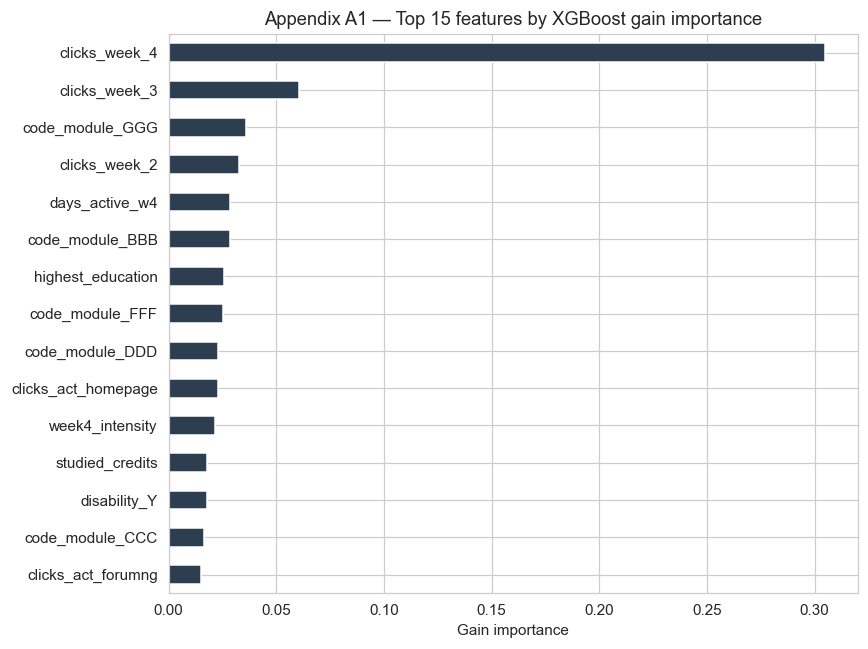


Top 10 features by gain importance:
clicks_week_4          0.3049
clicks_week_3          0.0608
code_module_GGG        0.0361
clicks_week_2          0.0329
days_active_w4         0.0287
code_module_BBB        0.0285
highest_education      0.0258
code_module_FFF        0.0251
code_module_DDD        0.0230
clicks_act_homepage    0.0229
dtype: float32


In [24]:
prep = pipe_xgb_tuned.named_steps["prep"]
xgb  = pipe_xgb_tuned.named_steps["model"]

feat_names = []
for name, trans, cols in prep.transformers_:
    if name == "imd":
        feat_names.extend(cols)
    elif name == "ord":
        feat_names.extend(cols)
    elif name == "nom":
        feat_names.extend(trans.named_steps["encode"].get_feature_names_out(cols).tolist())
    elif name == "num":
        feat_names.extend(cols)

imp = pd.Series(xgb.feature_importances_, index=feat_names)
top = imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top.plot.barh(ax=ax, color="#2c3e50")
ax.set_title("Appendix A1 — Top 15 features by XGBoost gain importance")
ax.set_xlabel("Gain importance")
plt.tight_layout()
plt.savefig("appx_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features by gain importance:")
print(imp.sort_values(ascending=False).head(10).round(4))


## Appendix A2 — Subgroup fairness audit by IMD band

Per-group error rates on the held-out test partition, evaluated for the tuned XGBoost model. The `Unknown` band appears as a distinct row, separate from the named deprivation bands.


In [25]:
imd_order = ['Unknown', '0-10%','10-20','20-30%','30-40%','40-50%',
             '50-60%','60-70%','70-80%','80-90%','90-100%']

audit_df = X_test.copy()
audit_df["imd_band"] = audit_df["imd_band"].fillna("Unknown")
audit_df["y_true"]      = y_test.values
audit_df["y_proba_xgb"] = proba_xgb_test
audit_df["y_pred_xgb"]  = (proba_xgb_test >= t_xgb).astype(int)

def per_group_kpis(g):
    yt, yp = g["y_true"], g["y_pred_xgb"]
    if len(g) < 20:
        return None
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return pd.Series({
        "n":                  len(g),
        "BaseRate":           yt.mean(),
        "FalsePositiveRate":  fp/(fp+tn) if (fp+tn) else np.nan,
        "FalseNegativeRate":  fn/(fn+tp) if (fn+tp) else np.nan,
        "Recall":             tp/(tp+fn) if (tp+fn) else np.nan,
        "Precision":          tp/(tp+fp) if (tp+fp) else np.nan,
    })

fairness = (audit_df.groupby("imd_band").apply(per_group_kpis)
            .dropna().round(3)
            .reindex([b for b in imd_order if b in audit_df["imd_band"].unique()]))
fairness.to_csv("appx_fairness_audit_by_imd.csv")
print(fairness)


              n  BaseRate  FalsePositiveRate  FalseNegativeRate  Recall  \
imd_band                                                                  
Unknown   217.0     0.313              0.242              0.309   0.691   
0-10%     698.0     0.649              0.661              0.060   0.940   
10-20     718.0     0.635              0.515              0.092   0.908   
20-30%    691.0     0.569              0.513              0.115   0.885   
30-40%    668.0     0.518              0.432              0.202   0.798   
40-50%    677.0     0.524              0.435              0.177   0.823   
50-60%    638.0     0.513              0.341              0.214   0.786   
60-70%    569.0     0.475              0.351              0.200   0.800   
70-80%    561.0     0.485              0.377              0.191   0.809   
80-90%    503.0     0.455              0.369              0.227   0.773   
90-100%   531.0     0.431              0.262              0.301   0.699   

          Precision  
im

## Appendix A3 — Ablation study: removal of `imd_band`

The cleanest empirical test of model reliance on the protected attribute is to remove `imd_band` from the feature matrix and refit the tuned XGBoost model, then to re-audit subgroup error rates by `imd_band` *off-features* (i.e. as a held-out grouping variable). A small AUC reduction combined with persistent group disparity in Appendix A2 indicates the disparity propagates through engagement features themselves — sharpening the ethics discussion in question 2.6.


In [26]:
# Reconstruct the preprocessor without the imd_band branch.
preprocessor_noimd = ColumnTransformer([
    ("ord", other_ordinal_pipe, other_ordinal_cols),
    ("nom", nominal_pipe,       NOMINAL_COLS),
    ("num", numeric_pipe,       NUMERIC_COLS),
])

X_train_noimd = X_train.drop(columns=["imd_band"])
X_test_noimd  = X_test.drop(columns=["imd_band"])

# Reuse the optimised hyperparameters from the full-feature search for a
# like-for-like comparison.
pipe_xgb_noimd = Pipeline([
    ("prep",  preprocessor_noimd),
    ("model", XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos,
        random_state=SEED,
        n_jobs=-1,
        **{k.replace("model__",""): v for k, v in search.best_params_.items()},
    )),
])
pipe_xgb_noimd.fit(X_train_noimd, y_train)

# Cross-validation AUC for the ablated model.
auc_cv_noimd = cross_val_score(pipe_xgb_noimd, X_train_noimd, y_train,
                               scoring="roc_auc", cv=cv, n_jobs=-1)

# Out-of-fold threshold selection mirrors the full-model procedure.
proba_xgb_noimd_oof = cross_val_predict(pipe_xgb_noimd, X_train_noimd, y_train,
                                        cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
t_noimd, _ = best_threshold(y_train, proba_xgb_noimd_oof)
proba_xgb_noimd_test = pipe_xgb_noimd.predict_proba(X_test_noimd)[:, 1]
kpi_noimd = full_kpis(y_test, proba_xgb_noimd_test, t_noimd)

ablation = pd.DataFrame({
    "P2 XGBoost (full)":        {"CV AUC mean": round(cv_xgb['auc'].mean(), 3),
                                 "CV AUC std":  round(cv_xgb['auc'].std(),  3),
                                 "Test AUC":    kpi_xgb["AUC"],
                                 "Test F1":     kpi_xgb["F1"],
                                 "Test Recall": kpi_xgb["Recall"],
                                 "Threshold":   round(t_xgb, 2)},
    "P2 XGBoost (no imd_band)": {"CV AUC mean": round(auc_cv_noimd.mean(), 3),
                                 "CV AUC std":  round(auc_cv_noimd.std(),  3),
                                 "Test AUC":    kpi_noimd["AUC"],
                                 "Test F1":     kpi_noimd["F1"],
                                 "Test Recall": kpi_noimd["Recall"],
                                 "Threshold":   round(t_noimd, 2)},
}).round(3)

ablation.to_csv("appx_ablation_no_imd.csv")
print(ablation)
print(f"\nDelta Test AUC after removal of imd_band: {kpi_noimd['AUC'] - kpi_xgb['AUC']:+.4f}")
print(f"Delta CV AUC mean:                         {auc_cv_noimd.mean() - cv_xgb['auc'].mean():+.4f}")


             P2 XGBoost (full)  P2 XGBoost (no imd_band)
CV AUC mean              0.821                     0.818
CV AUC std               0.005                     0.005
Test AUC                 0.821                     0.818
Test F1                  0.756                     0.751
Test Recall              0.834                     0.824
Threshold                0.350                     0.350

Delta Test AUC after removal of imd_band: -0.0028
Delta CV AUC mean:                         -0.0025


In [27]:
# Subgroup audit on the ablated model (imd_band as off-features grouping variable).
audit_df2 = X_test.copy()
audit_df2["imd_band"] = audit_df2["imd_band"].fillna("Unknown")
audit_df2["y_true"]   = y_test.values
audit_df2["y_proba"]  = proba_xgb_noimd_test
audit_df2["y_pred"]   = (proba_xgb_noimd_test >= t_noimd).astype(int)

def per_group_kpis2(g):
    yt, yp = g["y_true"], g["y_pred"]
    if len(g) < 20:
        return None
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return pd.Series({
        "n":                 len(g),
        "BaseRate":          yt.mean(),
        "FalsePositiveRate": fp/(fp+tn) if (fp+tn) else np.nan,
        "FalseNegativeRate": fn/(fn+tp) if (fn+tp) else np.nan,
    })

fairness_noimd = (audit_df2.groupby("imd_band").apply(per_group_kpis2)
                  .dropna().round(3)
                  .reindex([b for b in imd_order if b in audit_df2["imd_band"].unique()]))
fairness_noimd.to_csv("appx_fairness_audit_no_imd.csv")
print("Subgroup audit on the ablated model (imd_band removed from features):")
print(fairness_noimd)


Subgroup audit on the ablated model (imd_band removed from features):
              n  BaseRate  FalsePositiveRate  FalseNegativeRate
imd_band                                                       
Unknown   217.0     0.313              0.322              0.206
0-10%     698.0     0.649              0.518              0.130
10-20     718.0     0.635              0.397              0.123
20-30%    691.0     0.569              0.423              0.168
30-40%    668.0     0.518              0.432              0.208
40-50%    677.0     0.524              0.410              0.189
50-60%    638.0     0.513              0.373              0.205
60-70%    569.0     0.475              0.391              0.185
70-80%    561.0     0.485              0.436              0.188
80-90%    503.0     0.455              0.442              0.179
90-100%   531.0     0.431              0.331              0.236


---

## Output artefact inventory

For PDF report assembly, the notebook emits:

**Brief 3.2 — EDA figures (4):**
- `fig1_clicks_vs_outcome.png`
- `fig2_days_active_vs_outcome.png`
- `fig3_trend_vs_outcome.png`
- `fig4_education_vs_outcome.png`

**Brief 3.3 — Performance figures (3 of 4 permitted):**
- `fig5_confusion_matrices.png`
- `fig6_roc_curves.png`
- `fig7_threshold_sweep.png`

**Brief 4.1 / 4.2 — Tables:**
- `features_table.csv`
- `pipeline_comparison.csv`
- `kpi_results.csv`

**Appendices:**
- `appx_feature_importance.png`
- `appx_fairness_audit_by_imd.csv`
- `appx_fairness_audit_no_imd.csv`
- `appx_ablation_no_imd.csv`
